In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

data_path = "./FakeAVCeleb_v1.2/FakeAVCeleb_v1.2"

In [5]:
print(os.listdir(data_path))

['FakeVideo-FakeAudio', 'FakeVideo-RealAudio', 'meta_data.csv', 'README.txt', 'RealVideo-FakeAudio', 'RealVideo-RealAudio']


In [7]:
video_paths = []
labels = []

for category in os.listdir(data_path):
    category_path = os.path.join(data_path, category)

    if not os.path.isdir(category_path):
        continue

    # Assign label
    if "FakeVideo" in category:
        label = 0
    elif "RealVideo" in category:
        label = 1
    else:
        continue

    for race in os.listdir(category_path):
        race_path = os.path.join(category_path, race)

        for gender in os.listdir(race_path):
            gender_path = os.path.join(race_path, gender)

            for video_folder in os.listdir(gender_path):
                video_folder_path = os.path.join(gender_path, video_folder)

                for file in os.listdir(video_folder_path):
                    if file.endswith(".mp4"):
                        full_path = os.path.join(video_folder_path, file)
                        video_paths.append(full_path)
                        labels.append(label)

print("Total videos:", len(video_paths))

Total videos: 21544


## Testing to see if we can find a fake video

In [8]:
print(video_paths[0]) #find video path
print(labels[0]) # 0 for fake, 1 for real

./FakeAVCeleb_v1.2/FakeAVCeleb_v1.2\FakeVideo-FakeAudio\African\men\id00076\00109_10_id00476_wavtolip.mp4
0


## This was just to see if we can transverse through multiple files finding real videos whether its from fake audio or not because we don't care for audio

In [9]:
import random

real_indices = [i for i in range(len(labels)) if labels[i] == 1]

random_index = random.choice(real_indices)

print("Random real video:")
print(video_paths[random_index])

Random real video:
./FakeAVCeleb_v1.2/FakeAVCeleb_v1.2\RealVideo-RealAudio\Asian (East)\women\id03379\00032.mp4


## Here we test on 20% of the data and we train on 80% of the data.

In [10]:
from sklearn.model_selection import train_test_split

video_train, video_test, label_train, label_test = train_test_split(
    video_paths, labels, test_size=0.2, random_state=42
)

## We now set up the frames and resize before CNN.

In [11]:
import cv2

def extract_frames(video_path, max_frames=5):
    cap = cv2.VideoCapture(video_path)
    frames = []
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, total_frames // max_frames)
    
    for i in range(max_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        
        if not ret:
            break
        
        frames.append(frame)

    cap.release()
    return frames

In [12]:
X_train = []
y_train = []
video_source_train = []

fake_count = 0
real_count = 0
max_per_class = 1500 

for i in range(len(video_train)):

    # --- control FAKE ---
    if label_train[i] == 0:
        if fake_count >= max_per_class:
            continue
        fake_count += 1

    # --- control REAL ---
    elif label_train[i] == 1:
        if real_count >= max_per_class:
            continue
        real_count += 1

    frames = extract_frames(video_train[i])

    for frame in frames:
        frame = cv2.resize(frame, (128,128))
        frame = frame / 255.0

        X_train.append(frame)
        y_train.append(label_train[i])
        video_source_train.append(video_train[i])

# convert to numpy
X_train = np.array(X_train)
y_train = np.array(y_train)

print("Train shape:", X_train.shape)
print("Fake count:", fake_count)
print("Real count:", real_count)

Train shape: (11365, 128, 128, 3)
Fake count: 1500
Real count: 773


In [ ]:
X_test, y_test = [], []
video_source_test = []

for i in range(len(video_test)):
    frames = extract_frames(video_test[i])

    for frame in frames:
        frame = cv2.resize(frame, (128,128))
        frame = frame / 255.0

        X_test.append(frame)
        y_test.append(label_test[i])
        video_source_test.append(video_test[i])
        
X_test = np.array(X_test)
y_test = np.array(y_test)

print("Test shape:", X_test.shape)

NameError: name 'max_videos' is not defined

In [237]:
from sklearn.utils import shuffle

# Training set
X_train, y_train, video_source_train = shuffle(
    X_train, y_train, video_source_train, random_state=42
)

# Test set
X_test, y_test, video_source_test = shuffle(
    X_test, y_test, video_source_test, random_state=42
)

## This section is CNN set up, Conv layers they detect the patterns such as textures, fakes and edges. pooling reduces the size and keeps the relevant informations and dense will be the decision maker of if its real or fake.

In [238]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout

model = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [239]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [240]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


history = model.fit(
    X_train, y_train,
    epochs=20,  # allow more, it will stop early
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.6575 - loss: 0.6452 - val_accuracy: 0.9390 - val_loss: 0.4498
Epoch 2/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.6734 - loss: 0.5979 - val_accuracy: 0.9095 - val_loss: 0.3681
Epoch 3/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.7431 - loss: 0.5141 - val_accuracy: 0.8651 - val_loss: 0.3313
Epoch 4/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.7893 - loss: 0.4565 - val_accuracy: 0.8681 - val_loss: 0.3277
Epoch 5/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.8171 - loss: 0.4064 - val_accuracy: 0.8214 - val_loss: 0.3894
Epoch 6/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.8397 - loss: 0.3579 - val_accuracy: 0.8869 - val_loss: 0.3009
Epoch 7/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.8568 - loss: 0.3204 - val_accuracy: 0.9091 - val_loss: 0.2237
Epoch 8/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.8683 - loss: 0.2892 - 

In [241]:
y_pred = model.predict(X_test)
y_pred_labels = (y_pred > 0.5).astype(int)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


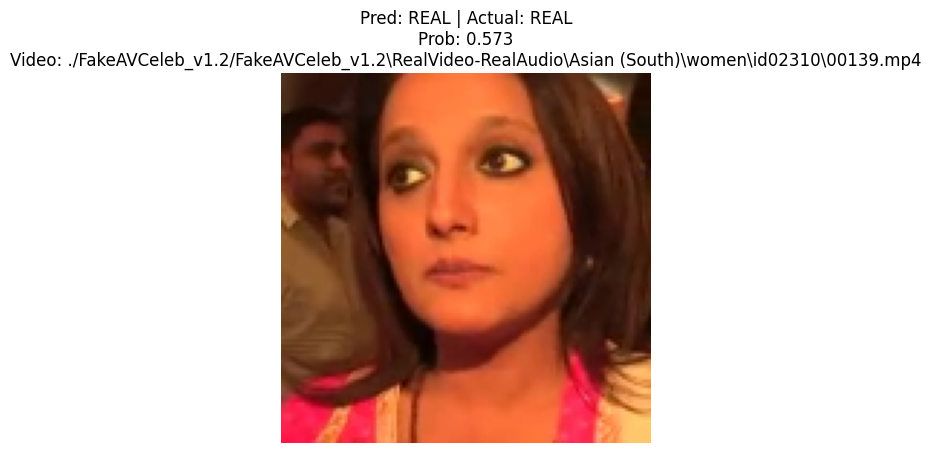

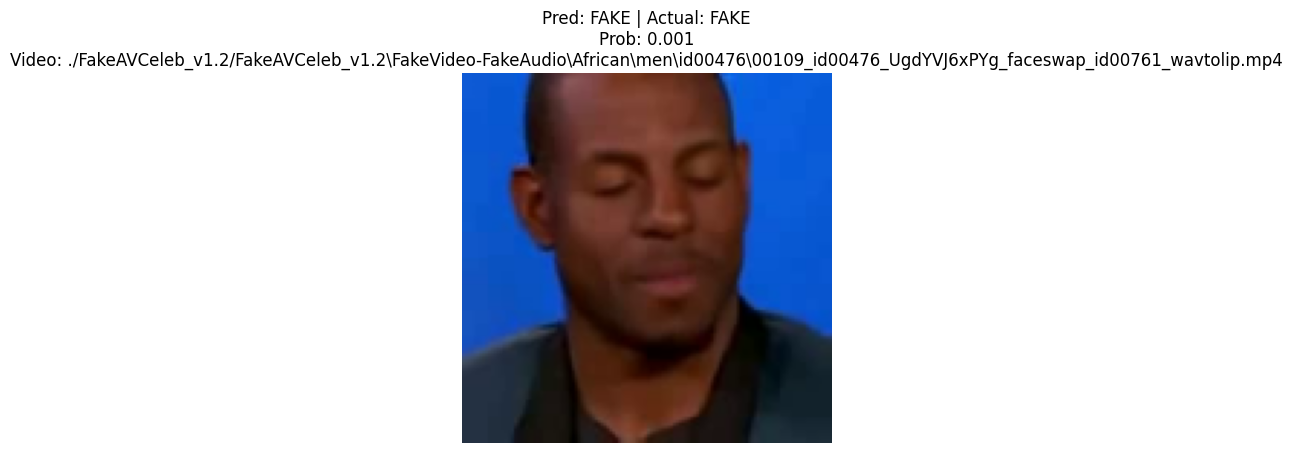

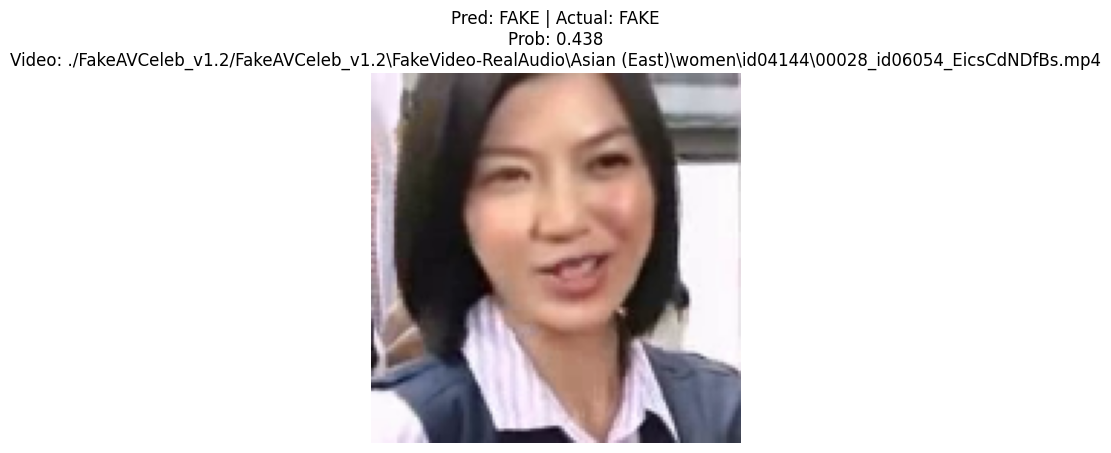

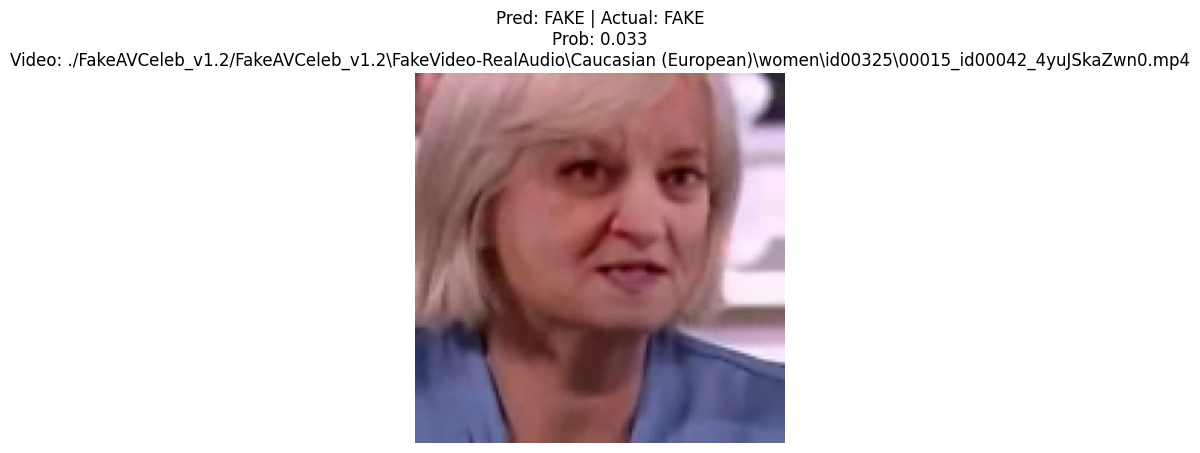

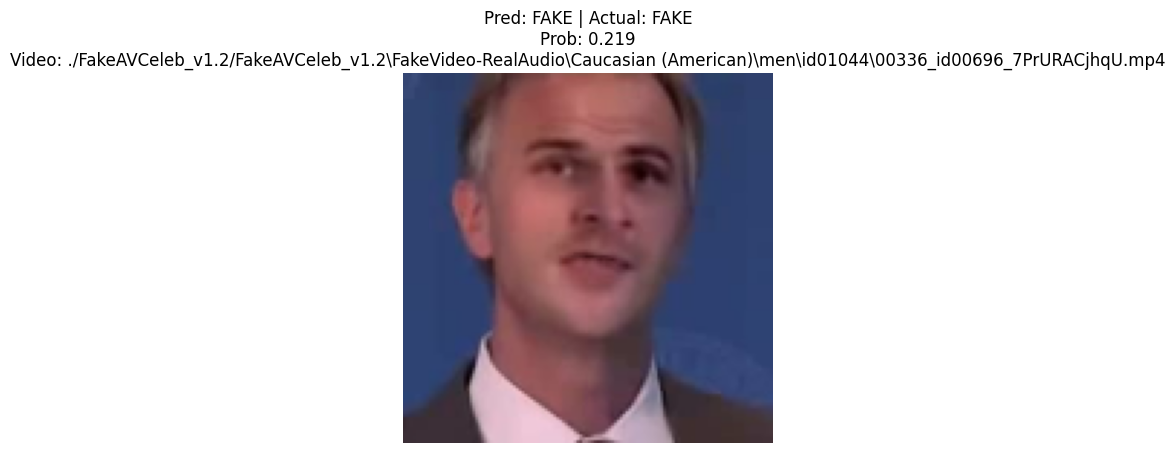

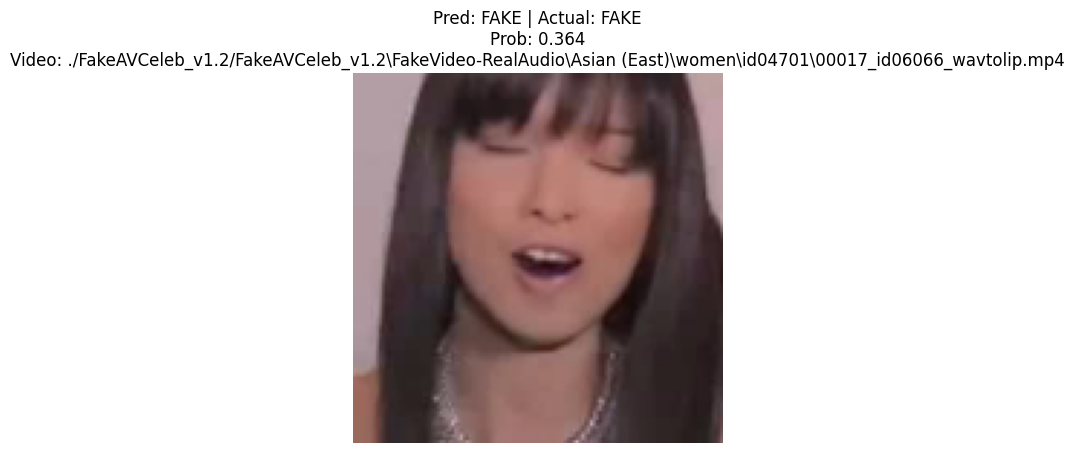

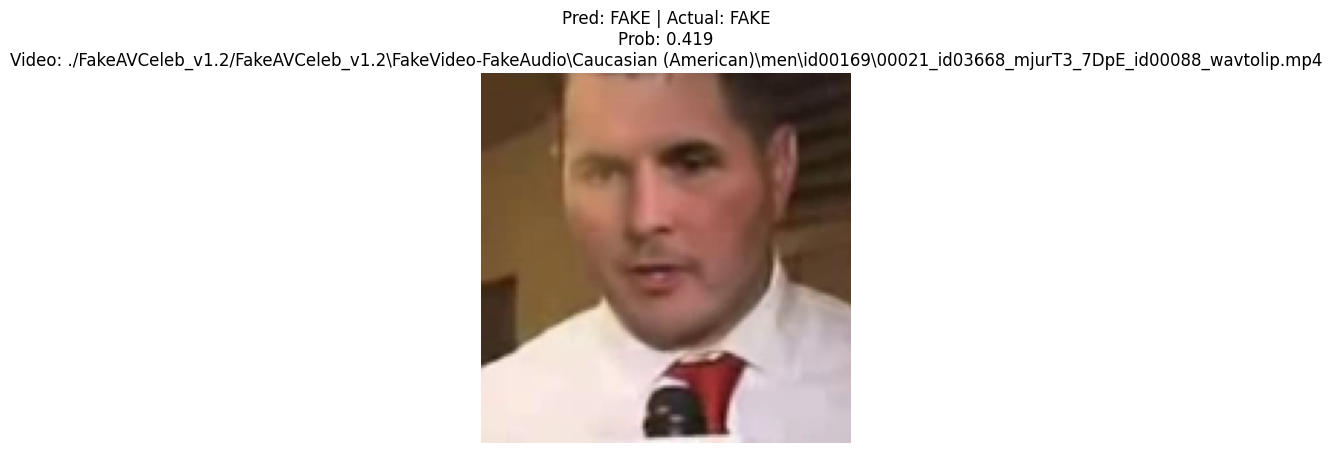

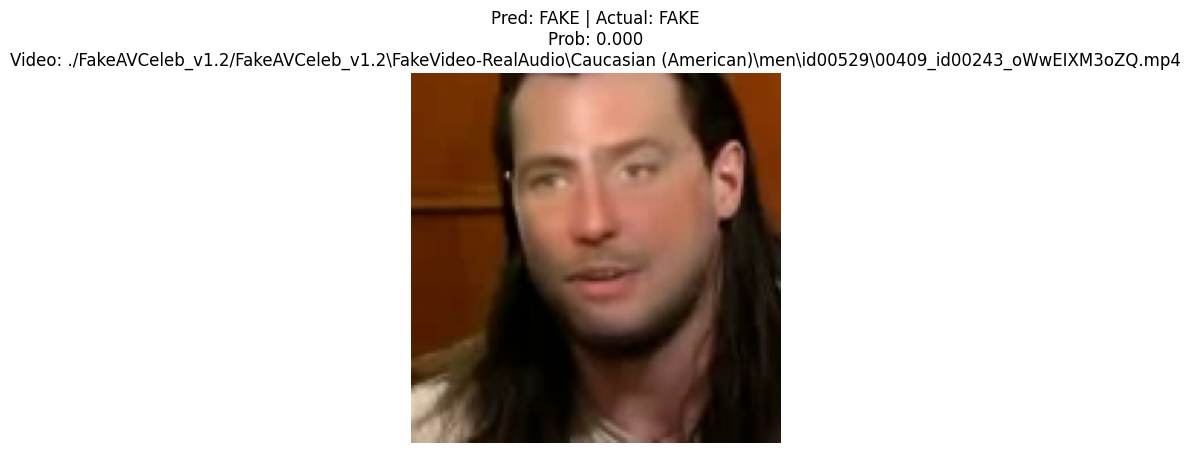

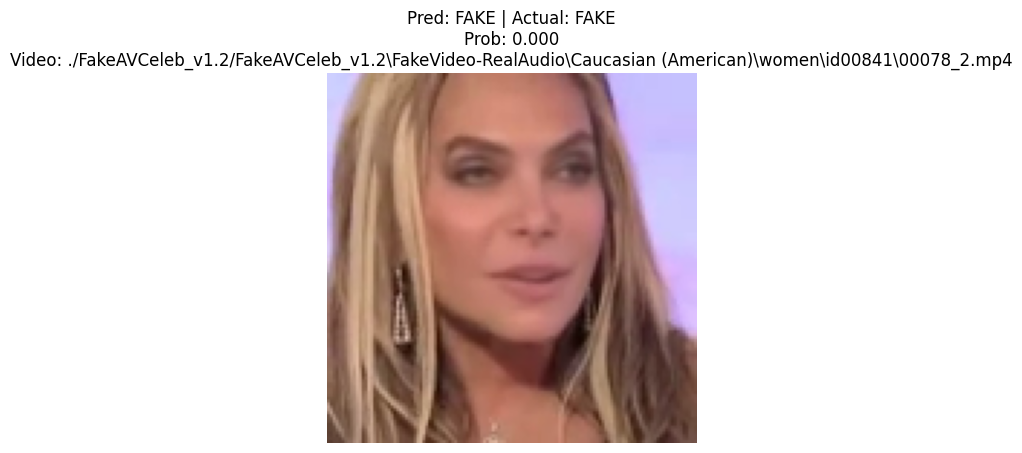

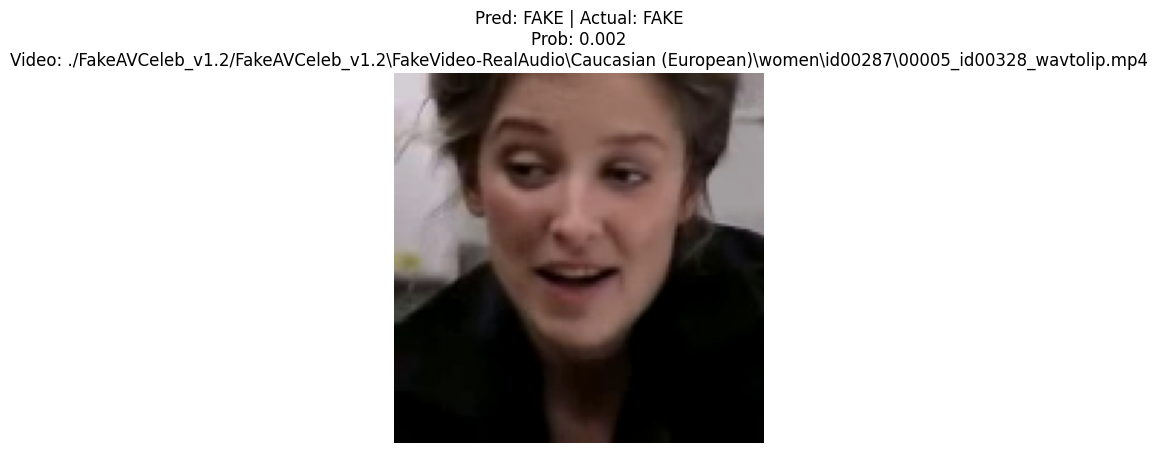

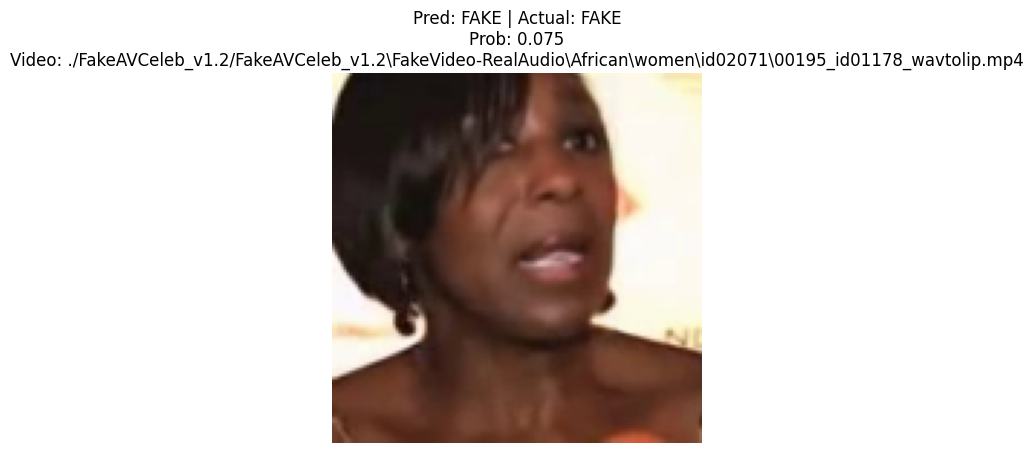

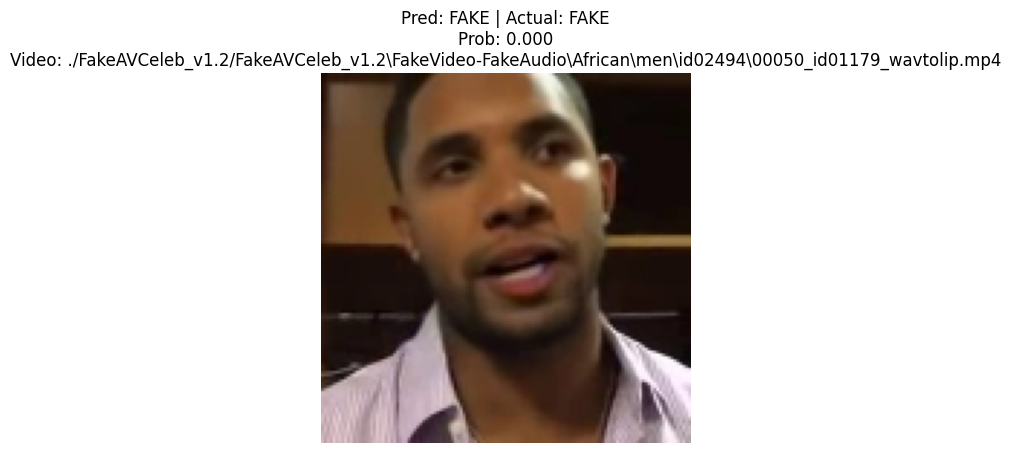

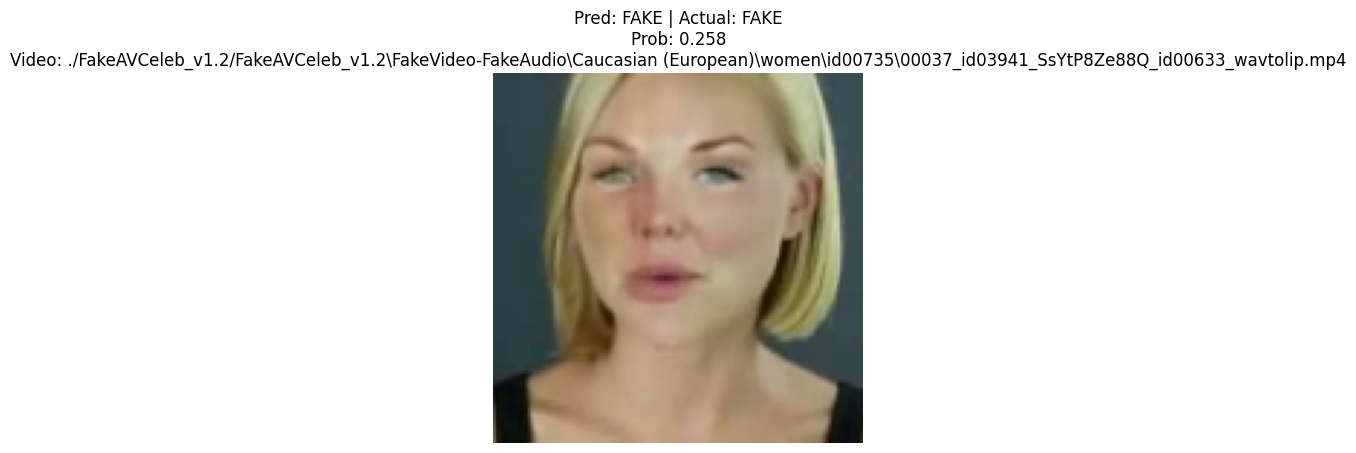

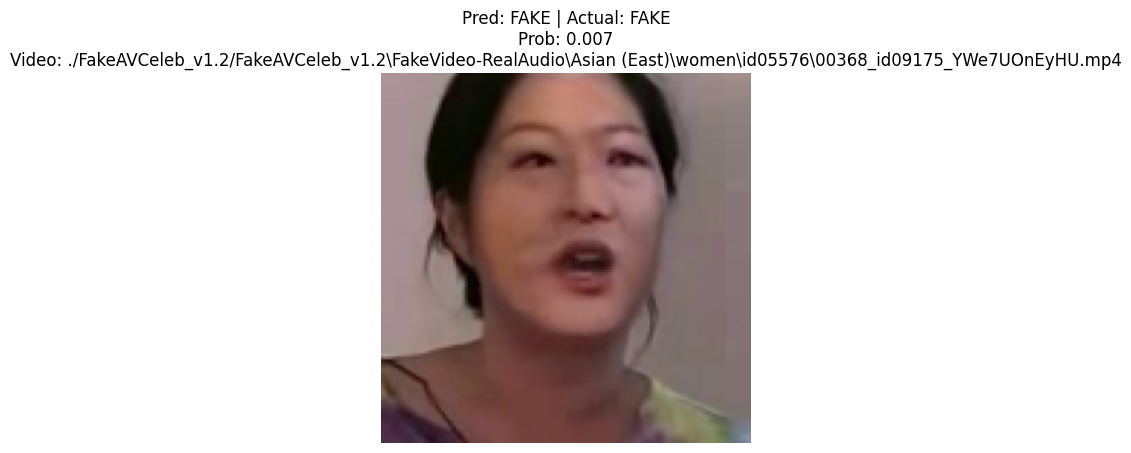

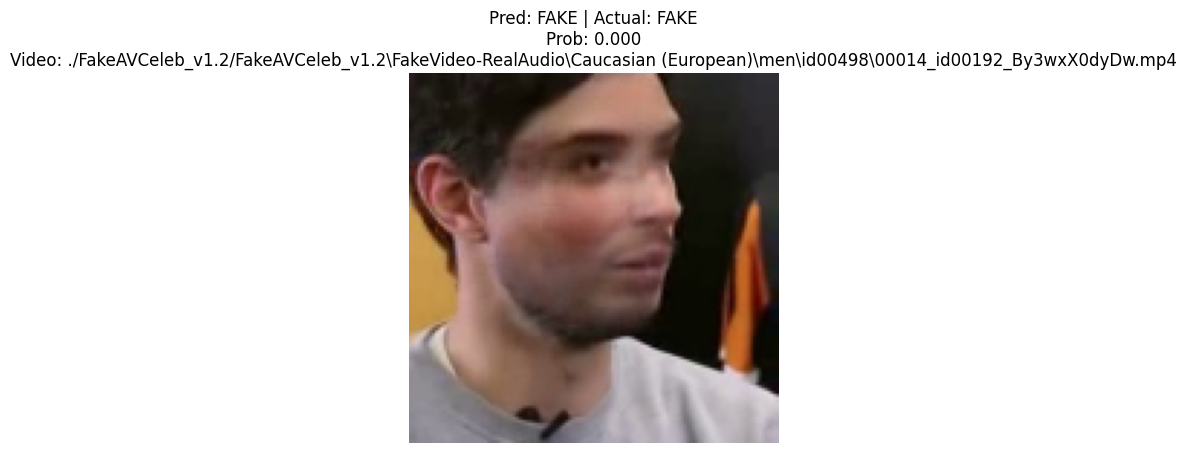

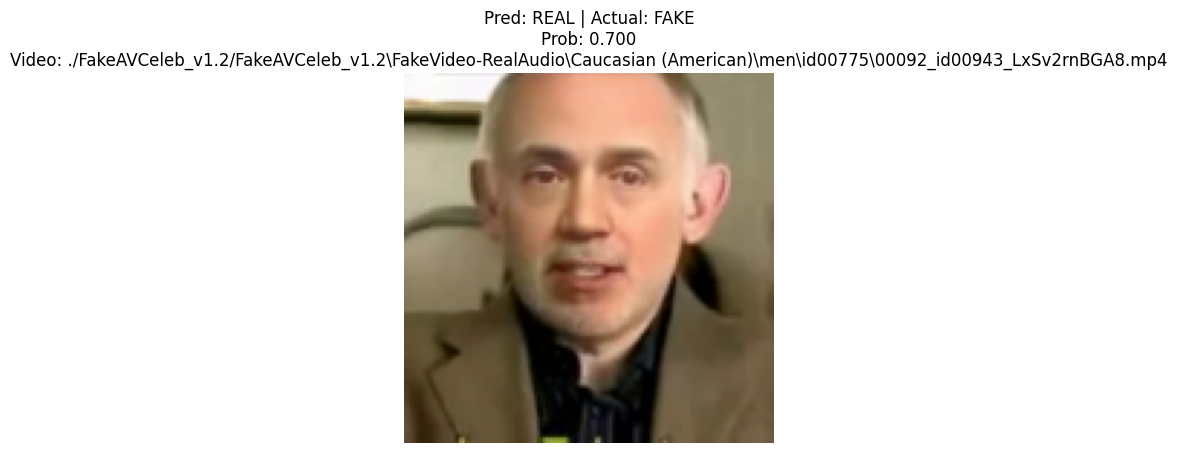

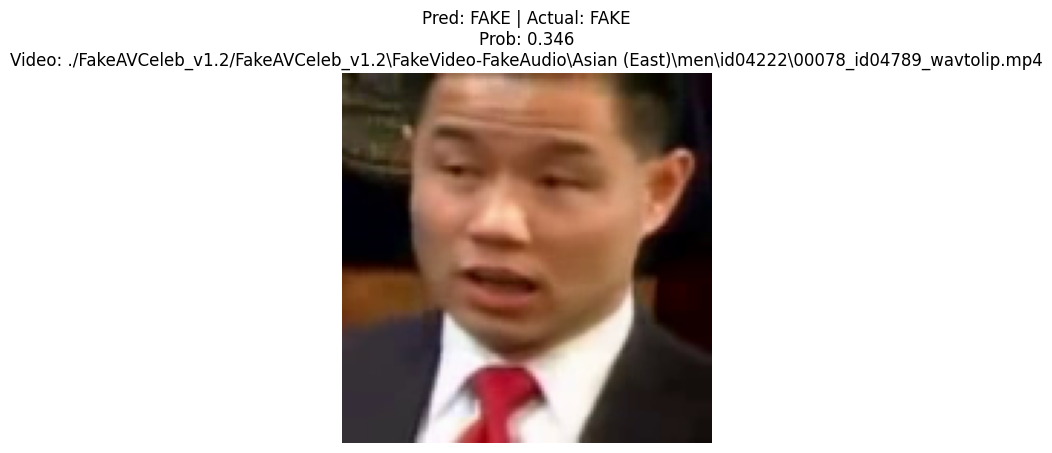

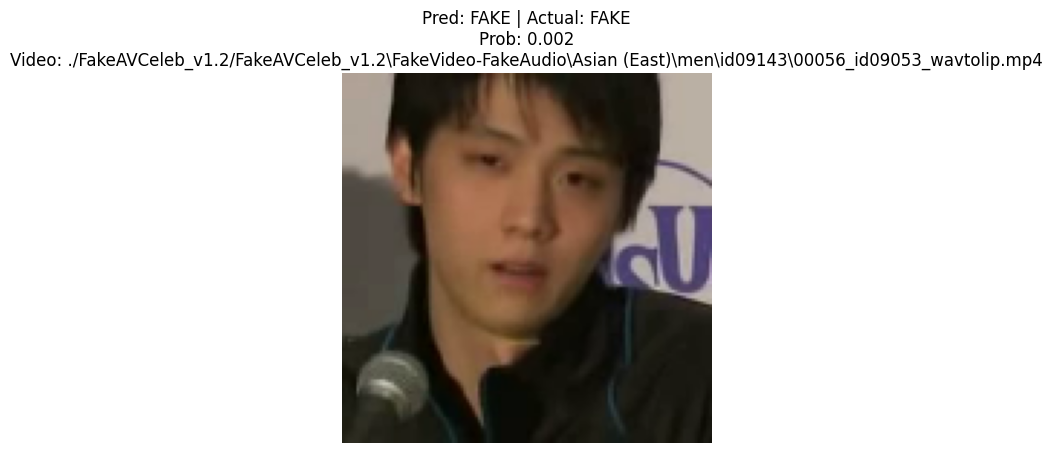

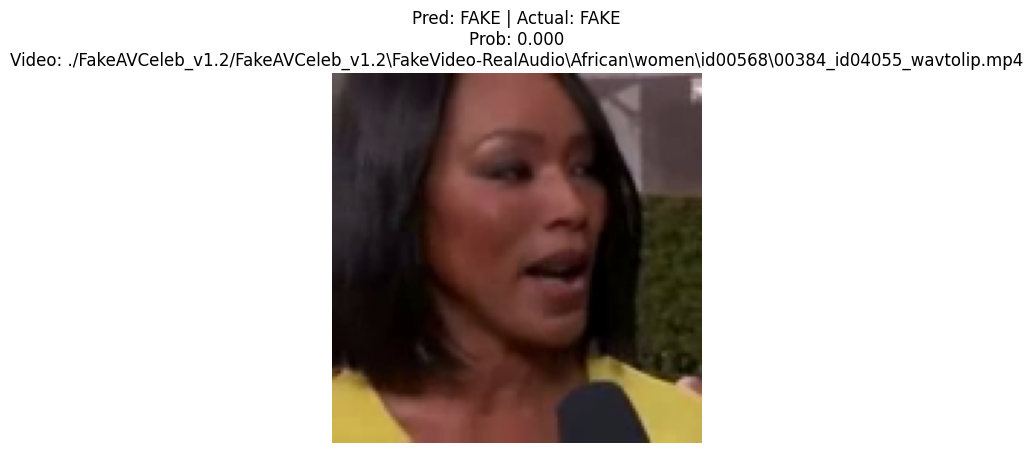

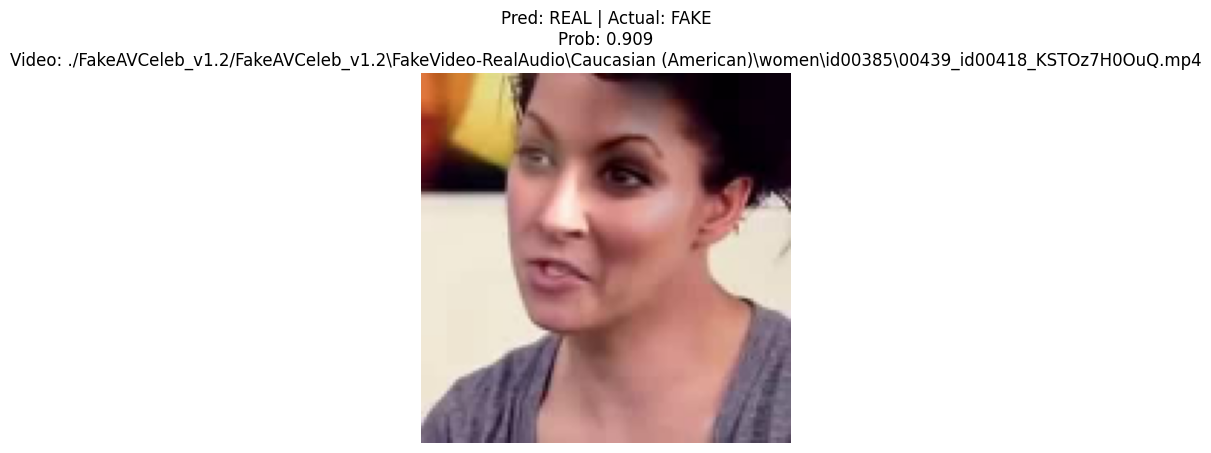

In [253]:
import random
import matplotlib.pyplot as plt

label_map = {0: "FAKE", 1: "REAL"}

indices = random.sample(range(len(X_test)), 20)  # pick 20 random samples

for i in indices:
    img = cv2.cvtColor((X_test[i]*255).astype('uint8'), cv2.COLOR_BGR2RGB)
    
    plt.imshow(img)
    plt.title(
    f"Pred: {label_map[y_pred_labels[i][0]]} | "
    f"Actual: {label_map[y_test[i]]}\n"
    f"Prob: {y_pred[i][0]:.3f}\n"
    f"Video: {video_source_test[i]}"
)
    plt.axis('off')
    plt.show()

In [254]:
correct = 0
wrong = 0

for i in indices:
    pred = y_pred_labels[i][0]
    actual = y_test[i]

    if pred == actual:
        correct += 1
    else:
        wrong += 1

print("Correct:", correct)
print("Wrong:", wrong)
print("Accuracy:", correct / (correct + wrong))

Correct: 18
Wrong: 2
Accuracy: 0.9


## Confusion Matrix 
TN = Fake -> Fake,
FP = Fake -> Real,
FN = Real -> Fake,
TP = Real -> Real.

In [2]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_labels)
print("Confusion Matrix:\n", cm)

TN, FP, FN, TP = cm.ravel()

print(f"TN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")

NameError: name 'y_test' is not defined